# Animal Welfare Policy Diffusion — ParlLawSpeech Analysis

This notebook investigates which country within the DE/AT/DK cluster is the discursive leader in farmed animal welfare legislation (2009–2019), and what diffusion mechanism the citation pattern implies.

The analysis runs in five stages: corpus construction, citation extraction, AI-assisted classification, adoption sequencing, and mixed-methods synthesis.

### Setup & configuration

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pyreadr
import pandas as pd
import re
import unicodedata
import os
import json as json_lib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

In [3]:
COUNTRIES = {
    'austria': 'AT',
    'germany': 'DE',
    'denmark': 'DK'
}

DOC_TYPES = ['laws', 'bills', 'speeches']

DATE_RANGE = (2009, 2019)


def normalise(text):
    """NFC-normalise and lowercase text for consistent keyword matching."""
    return unicodedata.normalize('NFC', str(text)).lower()


## Section 1: Data Loading

Data source: [ParlLawSpeech](https://parlawspeech.net) (Rauh et al., 2023). Documents are stored as RDS files in `data/Corpora_PLS_{country}/`. The nested dict `dfs[doc_type][country_code]` covers bills, laws, and speeches for AT, DE, and DK.

In [4]:
# Load all corpora into a nested dictionary: dfs[doc_type][country_code]
dfs = {}
for doc_type in DOC_TYPES:
    dfs[doc_type] = {}
    for country, code in COUNTRIES.items():
        path = f'data/Corpora_PLS_{country}/Corpus_{doc_type}_{country}.RDS'
        dfs[doc_type][code] = pyreadr.read_r(path)[None]

        print(f"Loaded {doc_type} [{code}]. (columns, rows): {dfs[doc_type][code].shape}")

Loaded laws [AT]. (columns, rows): (3030, 7)
Loaded laws [DE]. (columns, rows): (1638, 6)
Loaded laws [DK]. (columns, rows): (3220, 7)
Loaded bills [AT]. (columns, rows): (5926, 11)
Loaded bills [DE]. (columns, rows): (2445, 10)
Loaded bills [DK]. (columns, rows): (3615, 10)
Loaded speeches [AT]. (columns, rows): (204881, 14)
Loaded speeches [DE]. (columns, rows): (191932, 13)
Loaded speeches [DK]. (columns, rows): (716807, 11)


## Section 2: Corpus Construction Pipeline

### 2a: Keyword Filtering

Two-tier system: *core* terms name animal welfare directly; *broad* terms capture husbandry, slaughter, and transport legislation substantively about welfare without using the headline term. Text is NFC-normalised to lowercase before matching.

In [5]:
# Term lists — German (used for AT and DE)
core_de = ['tierschutz', 'tierwohl', 'nutztierhaltung']
broad_de = [
    'tierhaltung', 'schlachtung', 'tiertransport', 'haltungsbedingung',
    'kastenstand', 'schnabelkürzen', 'schwanzkupieren',
    'zähneschleifen', 'zähnekürzen',
    'käfighaltung', 'legebatterie', 'ausgestaltete käfige', 'vollspaltenboden',
]

# Term lists — Danish
core_dk = ['dyrevelfærd', 'dyrebeskyttelse', 'husdyrhold']
broad_dk = [
    'husdyrbrug', 'slagtning', 'dyretransport', 'staldforhold',
    'fareboks', 'nebtrimning', 'nebklipning',
    'halekupering', 'tandslibning', 'tandklipning',
    'burhold', 'buropdræt', 'batteribure', 'berigede bure', 'fuldspaltegulv',
]

TERM_LISTS = {
    'AT': (core_de, broad_de),
    'DE': (core_de, broad_de),
    'DK': (core_dk, broad_dk),
}

TEXT_COLUMNS = {
    'laws':     'law_text',
    'bills':    'bill_text',
    'speeches': 'text',
}


def classify_animal_welfare(text, core_terms, broad_terms):
    """Returns match tier ('core'|'broad'|'both'|'none') and matched terms."""
    t = normalise(text)
    core_matched  = [term for term in core_terms  if term in t]
    broad_matched = [term for term in broad_terms if term in t]
    if core_matched and broad_matched:
        tier = 'both'
    elif core_matched:
        tier = 'core'
    elif broad_matched:
        tier = 'broad'
    else:
        tier = 'none'
    return tier, core_matched, broad_matched


aw_dfs = {}
for doc_type, text_col in TEXT_COLUMNS.items():
    aw_dfs[doc_type] = {}
    for country in ['AT', 'DE', 'DK']:
        if doc_type not in dfs or country not in dfs[doc_type]:
            continue
        df = dfs[doc_type][country].copy()
        if text_col not in df.columns:
            continue
        core_terms, broad_terms = TERM_LISTS[country]
        results = df[text_col].apply(
            lambda x: classify_animal_welfare(x, core_terms, broad_terms)
        )
        df['aw_match_type']    = results.apply(lambda x: x[0])
        df['aw_core_matched']  = results.apply(lambda x: x[1])
        df['aw_broad_matched'] = results.apply(lambda x: x[2])
        df['is_aw']            = df['aw_match_type'] != 'none'
        aw_dfs[doc_type][country] = df[df['is_aw']].copy()
        total = len(df)
        n_aw  = df['is_aw'].sum()
        print(f"{doc_type.upper()} / {country}: {n_aw}/{total} ({100*n_aw/total:.1f}%) matched")

LAWS / AT: 85/3030 (2.8%) matched
LAWS / DE: 45/1638 (2.7%) matched
LAWS / DK: 65/3220 (2.0%) matched
BILLS / AT: 172/5926 (2.9%) matched
BILLS / DE: 124/2445 (5.1%) matched
BILLS / DK: 203/3615 (5.6%) matched
SPEECHES / AT: 1680/204881 (0.8%) matched
SPEECHES / DE: 1231/191932 (0.6%) matched
SPEECHES / DK: 2228/716807 (0.3%) matched


### 2b: Budget Act Exclusion

Austrian *Bundesfinanzgesetze*, Danish *Finanslov*, and German *Haushaltsgesetze* pass the keyword filter via Agriculture Ministry budget headings. They contain no substantive welfare provisions and are excluded by title-string matching before the procedure-ID seed set is built.

### 2c: Speech Exclusion

Speeches are excluded from the primary corpus: when included in the keyword seed set, the top Austrian procedure IDs are dominated by budget act proceedings (1,000+ speeches each), inflating `aw_procedure_ids` with non-welfare procedures.

### 2d: Procedure ID Linkage

A `procedure_ID` links all documents in the same legislative process (bill → amendments → enacted law). A law may not repeat the welfare keywords from its originating bill. Linkage recovers that continuity. Seed set: bills and laws only.

In [6]:
# Budget act exclusion runs FIRST so that budget procedure_IDs are never
# added to the seed set. If exclusion runs after ID extraction, budget
# procedures enter aw_procedure_ids and pull in their linked documents
# through the back door during the extension step below.

BUDGET_EXCLUSIONS = {
    'AT': ['bundesfinanzgesetz', 'bundesfinanzrahmengesetz',
           'finanzrahmengesetz'],
    'DE': ['bundesfinanzgesetz', 'haushaltsgesetz',
           'bundeshaushaltsplan', 'finanzplan', 'haushaltsjahr'],
    'DK': ['finanslov', 'bevillingslov', 'finansåret'],
}

def is_budget_act(title, country):
    if pd.isna(title):
        return False
    t = unicodedata.normalize('NFC', str(title)).lower()
    return any(term in t for term in BUDGET_EXCLUSIONS[country])

for doc_type, title_col in {'laws': 'title_law', 'bills': 'title_bill'}.items():
    for country in ['AT', 'DE', 'DK']:
        if country not in aw_dfs.get(doc_type, {}):
            continue
        df = aw_dfs[doc_type][country]
        is_budget = df[title_col].apply(lambda x: is_budget_act(x, country))
        n_excluded = is_budget.sum()
        if n_excluded > 0:
            print(f'{doc_type.upper()} / {country}: excluding {n_excluded} budget/omnibus acts')
            for _, row in df[is_budget].iterrows():
                print(f'    {row["procedure_ID"]}: {row[title_col]}')
        aw_dfs[doc_type][country] = df[~is_budget].copy()

# Procedure ID seed set built from the budget-excluded corpus
aw_procedure_ids = {}
for country in ['AT', 'DE', 'DK']:
    ids = set()
    for doc_type in ['laws', 'bills']:  # speeches excluded
        if doc_type not in aw_dfs or country not in aw_dfs[doc_type]:
            continue
        df = aw_dfs[doc_type][country]
        for val in df['procedure_ID'].dropna():
            for pid in str(val).split(','):
                pid = pid.strip()
                if pid:
                    ids.add(pid)
    aw_procedure_ids[country] = ids
    print(f'{country}: {len(ids)} unique procedure_IDs from flagged bills/laws')

# Retrieve all documents linked to those IDs (speeches excluded)
TEXT_COLUMNS = {
    'laws':  'law_text',
    'bills': 'bill_text',
}

aw_dfs_extended = {}

for doc_type, text_col in TEXT_COLUMNS.items():
    aw_dfs_extended[doc_type] = {}
    for country in ['AT', 'DE', 'DK']:
        if doc_type not in dfs or country not in dfs[doc_type]:
            continue
        df = dfs[doc_type][country].copy()
        flagged_ids = aw_procedure_ids[country]

        def has_flagged_id(val):
            if pd.isna(val) or str(val).strip() == '':
                return False
            for pid in str(val).split(','):
                if pid.strip() in flagged_ids:
                    return True
            return False

        df['in_aw_procedure'] = df['procedure_ID'].apply(has_flagged_id)

        if country in aw_dfs.get(doc_type, {}):
            keyword_flagged = aw_dfs[doc_type][country]
            keyword_idx = keyword_flagged.index
            df['is_aw'] = df.index.isin(keyword_idx)
            if 'aw_match_type' in keyword_flagged.columns:
                df = df.merge(
                    keyword_flagged[['aw_match_type', 'aw_core_matched', 'aw_broad_matched']],
                    left_index=True, right_index=True, how='left'
                )
                df['aw_match_type'] = df['aw_match_type'].fillna('linked')
                df['aw_core_matched'] = df['aw_core_matched'].apply(
                    lambda x: x if isinstance(x, list) else [])
                df['aw_broad_matched'] = df['aw_broad_matched'].apply(
                    lambda x: x if isinstance(x, list) else [])
        else:
            df['is_aw'] = False
            df['aw_match_type'] = 'none'
            df['aw_core_matched'] = [[] for _ in range(len(df))]
            df['aw_broad_matched'] = [[] for _ in range(len(df))]

        df_extended = df[df['is_aw'] | df['in_aw_procedure']].copy()
        aw_dfs_extended[doc_type][country] = df_extended

        n_keyword = df['is_aw'].sum()
        n_linked_only = (df['in_aw_procedure'] & ~df['is_aw']).sum()
        print(f'\n{doc_type.upper()} / {country}')
        print(f'  Keyword flagged:       {n_keyword}')
        print(f'  Added via procedure:   {n_linked_only}')
        print(f'  Total in extended set: {len(df_extended)}')

# Budget acts can re-enter aw_dfs_extended through the procedure-linkage path:
# the extension step searches the full unfiltered dfs for procedure ID matches,
# so a budget act that shares a procedure ID with a legitimate AW bill slips back
# in even though it was excluded from aw_dfs above. A second pass closes this.
title_cols = {'laws': 'title_law', 'bills': 'title_bill'}
for doc_type in ['laws', 'bills']:
    for country in ['AT', 'DE', 'DK']:
        if country not in aw_dfs_extended.get(doc_type, {}):
            continue
        df = aw_dfs_extended[doc_type][country]
        title_col = title_cols[doc_type]
        if title_col in df.columns:
            is_budget = df[title_col].apply(lambda x: is_budget_act(x, country))
            n_removed = is_budget.sum()
            if n_removed:
                print(f'Post-extension budget exclusion {doc_type}/{country}: '
                      f'removed {n_removed} additional budget act(s)')
            aw_dfs_extended[doc_type][country] = df[~is_budget].copy()

# International agreement ratification exclusion
# EU trade / diplomatic agreements ratified by national parliaments often contain
# peripheral animal welfare mentions (e.g. as one clause in an FTA), causing them
# to pass the keyword filter. Their country references are co-signatories listed
# in the agreement text, not peer policy citations.
#
# Exclusion rule: title contains an international agreement signal phrase
# AND does NOT contain an animal welfare term in the title itself.
# The AW title carve-out preserves Council of Europe animal welfare conventions
# (e.g. ETS 125 on transport of animals) which genuinely belong in the corpus.

INTL_PATTERNS = {
    'DE': [
        'abkommen zwischen', 'übereinkommen zwischen',
        'zustimmungsgesetz zu', 'zustimmungsgesetz zum',
        'ratifikationsgesetz',
        # EU institutional / enlargement acts
        'der europäischen union', 'des europäischen parlaments',
        'eu-erweiterung', 'beitritt der',
    ],
    'AT': [
        'abkommen zwischen', 'übereinkommen zwischen',
        'ratifizierungsgesetz',
        'der europäischen union', 'des europäischen parlaments',
        'eu-erweiterung', 'beitritt der',
    ],
    'DK': [
        'aftale mellem', 'overenskomst mellem',
        'konvention om', 'ratificering af',
        # EU institutional / enlargement acts
        'den europæiske unions', 'det europæiske parlaments',
        'eu\'s udvidelse', 'udvidelse med', 'tiltrædelse af den',
    ],
}

AW_TITLE_TERMS = ['tier', 'animal', 'dyr', 'welfare', 'wohl', 'husdyr', 'schlacht', 'slagt']


def is_intl_agreement(title, country):
    if pd.isna(title):
        return False
    t = unicodedata.normalize('NFC', str(title)).lower()
    is_agreement = any(p in t for p in INTL_PATTERNS.get(country, []))
    if not is_agreement:
        return False
    # Carve out: keep if the title itself signals animal welfare
    has_aw = any(term in t for term in AW_TITLE_TERMS)
    return not has_aw


for doc_type, title_col in {'laws': 'title_law', 'bills': 'title_bill'}.items():
    for country in ['AT', 'DE', 'DK']:
        if country not in aw_dfs_extended.get(doc_type, {}):
            continue
        df = aw_dfs_extended[doc_type][country]
        if title_col not in df.columns:
            continue
        is_intl = df[title_col].apply(lambda x: is_intl_agreement(x, country))
        n_removed = is_intl.sum()
        if n_removed:
            print(f'International agreement exclusion {doc_type}/{country}: '
                  f'removed {n_removed} document(s)')
            for _, row in df[is_intl].head(5).iterrows():
                print(f'    {row[title_col]}')
        aw_dfs_extended[doc_type][country] = df[~is_intl].copy()


LAWS / AT: excluding 7 budget/omnibus acts
    26_14 d.B.: Bundesfinanzgesetz 2019 - BFG 2019 samt Anlagen
    26_13 d.B.: Bundesfinanzgesetz 2018 - BFG 2018 samt Anlagen
    25_1260 d.B.: Bundesfinanzgesetz 2017 – BFG 2017 samt Anlagen
    25_820 d.B.: Bundesfinanzgesetz 2016 - BFG 2016 samt Anlagen
    25_51 d.B.: Bundesfinanzgesetz 2015 - BFG 2015 samt Anlagen
    25_50 d.B.: Bundesfinanzgesetz 2014 - BFG 2014 samt Anlagen
    24_1910 d.B.: Bundesfinanzgesetz 2013 - BFG 2013 samt Anlagen
LAWS / DK: excluding 9 budget/omnibus acts
    L 1_2021_22: Finanslov for finansåret 2022
    L 1_2020_21: Finanslov for finansåret 2021
    L 1_2019_20: Finanslov for finansåret 2020
    L 1_2018_19_01: Finanslov for finansåret 2019
    L 1_2016_17: Finanslov for finansåret 2017
    L 1_2015_16: Finanslov for finansåret 2016
    L 1_2013_14: Finanslov for finansåret 2014
    L 1_2012_13: Finanslov for finansåret 2013
    L 1_2014_15_01: Finanslov for finansåret 2015
BILLS / AT: excluding 13 budget/

### 2e: Date Range Filtering (2009–2019)

Laws filtered on `adoption_date`; bills on `initiation_date`. 2009 is the earliest year with full three-country ParlLawSpeech coverage.

In [7]:
# DATE RANGE FILTERING
# Restrict aw_dfs_extended to the study window 2009-2019

def apply_date_filter(dfs_extended, date_range):
    """
    Filter the extended corpus to the study date range.
    Laws are filtered on adoption_date; bills on initiation_date.
    Returns corpus[doc_type][country].
    """
    start, end = date_range
    date_cols = {'laws': 'adoption_date', 'bills': 'initiation_date'}
    corpus = {}
    for doc_type, df_by_country in dfs_extended.items():
        corpus[doc_type] = {}
        date_col = date_cols.get(doc_type)
        for country, df in df_by_country.items():
            if date_col and date_col in df.columns:
                dates = pd.to_datetime(df[date_col], errors='coerce')
                mask = (dates.dt.year >= start) & (dates.dt.year <= end)
                corpus[doc_type][country] = df[mask].copy()
            else:
                # No date column available — keep all (conservative fallback)
                corpus[doc_type][country] = df.copy()
    return corpus

corpus = apply_date_filter(aw_dfs_extended, DATE_RANGE)

print(f'Final corpus after date filter ({DATE_RANGE[0]}–{DATE_RANGE[1]}):')
for doc_type in ['laws', 'bills']:
    for country in ['AT', 'DE', 'DK']:
        df = corpus[doc_type][country]
        kw = (df['aw_match_type'] != 'linked').sum()
        linked = (df['aw_match_type'] == 'linked').sum()
        print(f'  {doc_type:5s}/{country}: {len(df):4d} total  (keyword: {kw}, linked: {linked})')


Final corpus after date filter (2009–2019):
  laws /AT:   38 total  (keyword: 36, linked: 2)
  laws /DE:   52 total  (keyword: 28, linked: 24)
  laws /DK:  114 total  (keyword: 38, linked: 76)
  bills/AT:   57 total  (keyword: 56, linked: 1)
  bills/DE:   66 total  (keyword: 63, linked: 3)
  bills/DK:  126 total  (keyword: 124, linked: 2)


In [8]:
# CORPUS SUMMARY TABLE

rows = []
for doc_type in ['laws', 'bills']:
    for country in ['AT', 'DE', 'DK']:
        df = corpus[doc_type][country]
        rows.append({
            'doc_type': doc_type,
            'country': country,
            'total': len(df),
            'keyword_matched': (df['aw_match_type'] != 'linked').sum(),
            'procedure_linked': (df['aw_match_type'] == 'linked').sum(),
        })

summary = pd.DataFrame(rows)
pivot = summary.pivot_table(
    index='doc_type', columns='country',
    values=['keyword_matched', 'procedure_linked', 'total'],
    aggfunc='sum'
)
print('Table 1: Final corpus composition\n')
print(pivot.to_string())

Table 1: Final corpus composition

         keyword_matched          procedure_linked         total         
country               AT  DE   DK               AT  DE  DK    AT  DE   DK
doc_type                                                                 
bills                 56  63  124                1   3   2    57  66  126
laws                  36  28   38                2  24  76    38  52  114


## Section 3: Quantitative Analysis — Foreign Country Citation Counting

Country names searched across German, Danish, and English variants with `\b` word-boundary regex. Adjectives that also describe languages (*deutsche*, *dansk*, *danish*) are excluded to avoid false positives in language-reference contexts. SE and CH are included as reference countries alongside the trio.

In [9]:
# Country name variants across DE / DK / EN.
#
# Adjectives that also describe a language ('german', 'danish', 'deutsche',
# 'dänisch', 'dansk') are intentionally excluded: they produce false positives
# wherever legislation refers to a German-language or Danish-language text
# (e.g. "translation into German", "deutsche Übersetzung"). Unambiguous nouns
# and proper names are retained. This exclusion is documented as a limitation.
COUNTRY_NAMES = {
    'DE': ['deutschland', 'germany', 'tyskland'],
    'AT': ['österreich', 'austria', 'østrig'],
    'DK': ['dänemark', 'dänen', 'denmark', 'danmark', 'dansker', 'danskerne'],
    'SE': ['schweden', 'sweden', 'sverige'],
    'CH': ['schweiz', 'switzerland', 'svejts'],
    # Added: NL and UK are top-5 API-rated countries; included as secondary
    # reference countries alongside SE and CH.
    # Language adjectives ('dutch', 'niederländisch') excluded on the same
    # basis as 'danish'/'dänisch' — false positives in language contexts.
    # 'england' excluded — too ambiguous (region, sport, historical use).
    'NL': ['niederlande', 'niederlanden', 'netherlands', 'holland',
           'nederlandene', 'nederlanderne'],
    'UK': ['vereinigtes königreich', 'großbritannien', 'great britain',
           'united kingdom', 'storbritannien', 'det forenede kongerige'],
}


def count_foreign_references(text, country_names, exclude_self=None, return_contexts=False):
    t = normalise(text)
    counts = {}
    contexts = []

    for country_code, variants in country_names.items():
        if country_code == exclude_self:
            continue
        pattern = r'\b(' + '|'.join(re.escape(v) for v in variants) + r')\b'
        matches = list(re.finditer(pattern, t, re.IGNORECASE | re.UNICODE))
        counts[country_code] = len(matches)
        if return_contexts:
            for m in matches:
                start = max(0, m.start() - 600)
                end   = min(len(t), m.end() + 600)
                contexts.append({
                    'cited_country': country_code,
                    'match_text': m.group(),
                    'context': t[start:end],
                })

    if return_contexts:
        return counts, contexts
    return counts


def build_citation_dataframe(corpus_subset, doc_type, citing_country,
                              country_names, id_col, date_col, title_col,
                              text_col, return_contexts=False):
    rows = []
    all_contexts = []

    for _, row in corpus_subset.iterrows():
        text = str(row.get(text_col, ''))
        if return_contexts:
            counts, ctxs = count_foreign_references(
                text, country_names, exclude_self=citing_country,
                return_contexts=True)
            for c in ctxs:
                c.update({'citing_country': citing_country, 'doc_type': doc_type,
                          'doc_id': row.get(id_col, ''),
                          'title': row.get(title_col, ''),
                          'date': row.get(date_col, '')})
            all_contexts.extend(ctxs)
        else:
            counts = count_foreign_references(
                text, country_names, exclude_self=citing_country)

        record = {
            'doc_type': doc_type,
            'citing_country': citing_country,
            'doc_id': row.get(id_col, ''),
            'date': row.get(date_col, ''),
            'title': row.get(title_col, ''),
        }
        record.update({f'ref_{k}': v for k, v in counts.items()})
        rows.append(record)

    df = pd.DataFrame(rows)
    if return_contexts:
        return df, pd.DataFrame(all_contexts)
    return df


In [10]:
# CITATION COUNTING — LAWS
FIELD_MAP = {
    'laws':  {'id': 'law_ID',    'date': 'adoption_date',  'title': 'title_law',  'text': 'law_text'},
    'bills': {'id': 'bill_ID',   'date': 'initiation_date','title': 'title_bill', 'text': 'bill_text'},
}

law_citation_dfs = []
law_context_dfs  = []

for country in ['AT', 'DE', 'DK']:
    df_sub = corpus['laws'][country]
    fm = FIELD_MAP['laws']
    cdf, ctxdf = build_citation_dataframe(
        df_sub, 'laws', country, COUNTRY_NAMES,
        id_col=fm['id'], date_col=fm['date'], title_col=fm['title'], text_col=fm['text'],
        return_contexts=True
    )
    law_citation_dfs.append(cdf)
    law_context_dfs.append(ctxdf)
    total_refs = cdf[[c for c in cdf.columns if c.startswith('ref_')]].sum().sum()
    print(f'{country} laws: {len(cdf)} documents, {int(total_refs)} total foreign references')

laws_citations = pd.concat(law_citation_dfs, ignore_index=True)
laws_contexts  = pd.concat(law_context_dfs,  ignore_index=True)
print(f'\nTotal law contexts extracted: {len(laws_contexts)}')


AT laws: 38 documents, 32 total foreign references
DE laws: 52 documents, 5 total foreign references
DK laws: 114 documents, 5 total foreign references

Total law contexts extracted: 42


In [11]:
# CITATION COUNTING — BILLS
bill_citation_dfs = []
bill_context_dfs  = []

for country in ['AT', 'DE', 'DK']:
    df_sub = corpus['bills'][country]
    fm = FIELD_MAP['bills']
    cdf, ctxdf = build_citation_dataframe(
        df_sub, 'bills', country, COUNTRY_NAMES,
        id_col=fm['id'], date_col=fm['date'], title_col=fm['title'], text_col=fm['text'],
        return_contexts=True
    )
    bill_citation_dfs.append(cdf)
    bill_context_dfs.append(ctxdf)
    total_refs = cdf[[c for c in cdf.columns if c.startswith('ref_')]].sum().sum()
    print(f'{country} bills: {len(cdf)} documents, {int(total_refs)} total foreign references')

bills_citations = pd.concat(bill_citation_dfs, ignore_index=True)
bills_contexts  = pd.concat(bill_context_dfs,  ignore_index=True)
print(f'\nTotal bill contexts extracted: {len(bills_contexts)}')

all_citations = pd.concat([laws_citations, bills_citations], ignore_index=True)
all_contexts  = pd.concat([laws_contexts,  bills_contexts],  ignore_index=True)
print(f'\nCombined: {len(all_citations)} documents, {len(all_contexts)} citation contexts')


AT bills: 57 documents, 59 total foreign references
DE bills: 66 documents, 46 total foreign references
DK bills: 126 documents, 208 total foreign references

Total bill contexts extracted: 313

Combined: 453 documents, 355 citation contexts


Citation matrix (rows=citing country, cols=cited country):
          DE   DK  SE  CH  NL  UK    AT
citing                                 
AT      13.0  6.0   6  54   7   5   0.0
DE       0.0  4.0   1  22   8   9   7.0
DK      80.0  0.0  59  18  18  23  15.0


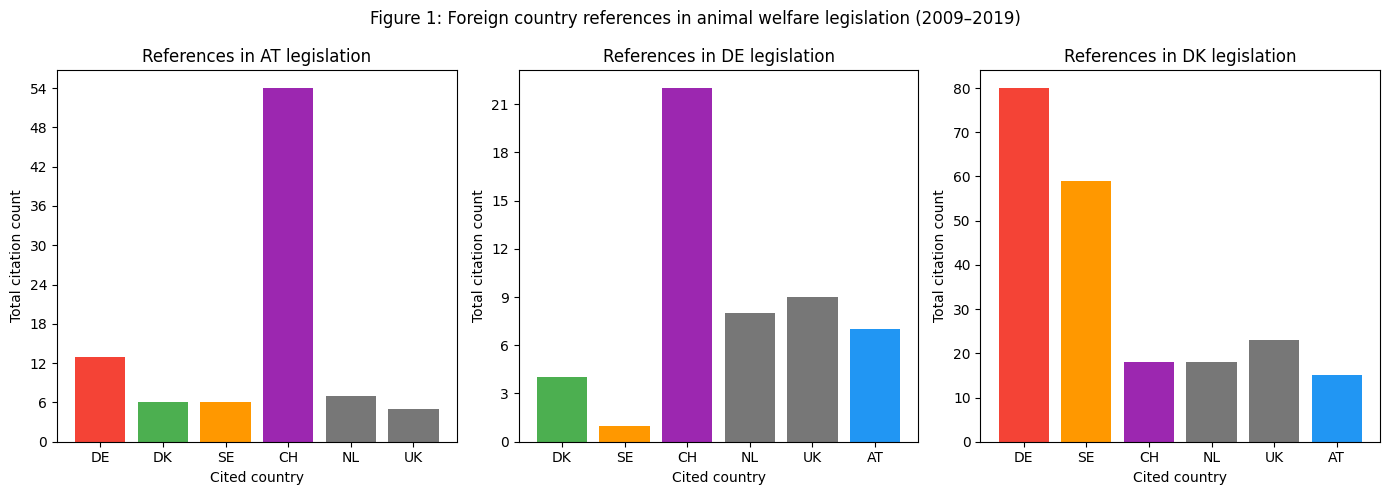

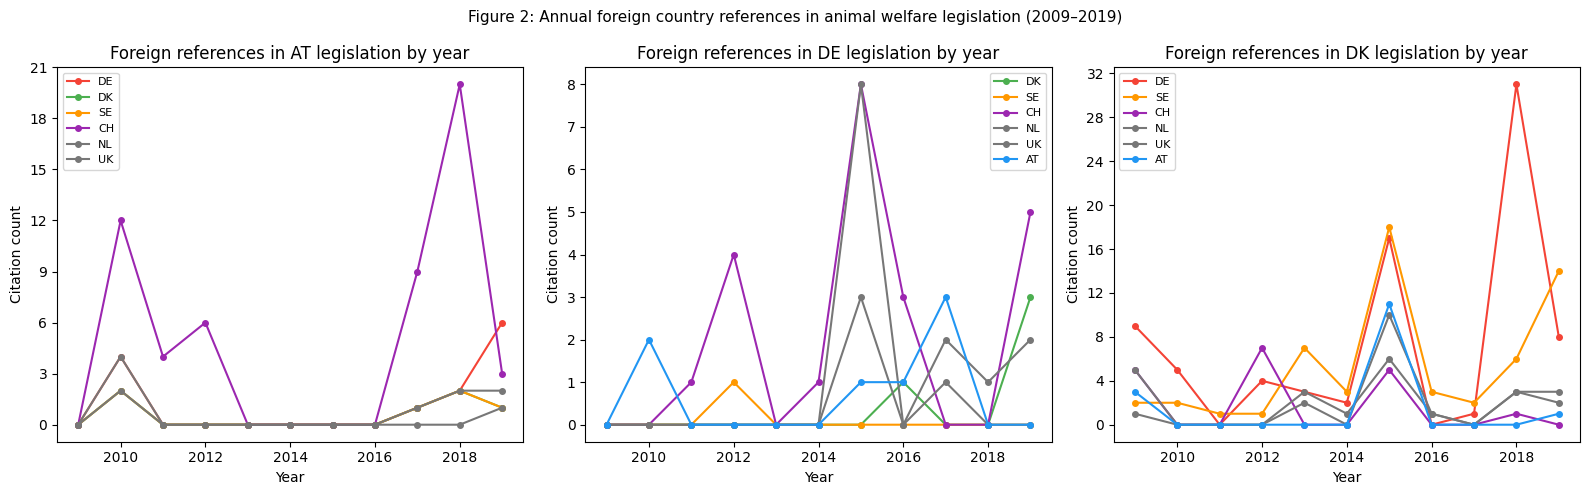

In [12]:
# ── Citation matrix ──────────────────────────────────────────────────────────
ref_cols = [c for c in all_citations.columns if c.startswith('ref_')]
cited_countries = [c.replace('ref_', '') for c in ref_cols]

matrix_rows = []
for country in ['AT', 'DE', 'DK']:
    sub = all_citations[all_citations['citing_country'] == country]
    row = {'citing': country}
    for rc, cc in zip(ref_cols, cited_countries):
        row[cc] = sub[rc].sum()
    matrix_rows.append(row)

matrix_df = pd.DataFrame(matrix_rows).set_index('citing')
print('Citation matrix (rows=citing country, cols=cited country):')
print(matrix_df.to_string())

# ── Bar chart: breakdown by cited country per citing country ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
colors = {'AT': '#2196F3', 'DE': '#F44336', 'DK': '#4CAF50', 'SE': '#FF9800', 'CH': '#9C27B0'}

for ax, citing in zip(axes, ['AT', 'DE', 'DK']):
    row = matrix_df.loc[citing].drop(citing, errors='ignore')
    bar_colors = [colors.get(c, '#777') for c in row.index]
    ax.bar(row.index, row.values, color=bar_colors)
    ax.set_title(f'References in {citing} legislation')
    ax.set_xlabel('Cited country')
    ax.set_ylabel('Total citation count')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.suptitle('Figure 1: Foreign country references in animal welfare legislation (2009–2019)',
             fontsize=12)
plt.tight_layout()
plt.savefig('data/fig1_citation_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Year-by-year trend ────────────────────────────────────────────────────────
all_citations['year'] = pd.to_datetime(all_citations['date'], errors='coerce').dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, citing in zip(axes, ['AT', 'DE', 'DK']):
    sub = all_citations[all_citations['citing_country'] == citing]
    for rc, cc in zip(ref_cols, cited_countries):
        if cc == citing:
            continue
        yearly = sub.groupby('year')[rc].sum().reindex(range(2009, 2020), fill_value=0)
        ax.plot(yearly.index, yearly.values, label=cc, color=colors.get(cc, '#777'), marker='o', ms=4)
    ax.set_title(f'Foreign references in {citing} legislation by year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Citation count')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.suptitle('Figure 2: Annual foreign country references in animal welfare legislation (2009–2019)',
             fontsize=11)
plt.tight_layout()
plt.savefig('data/fig2_citation_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# PER-DOCUMENT CITATION RATES
# Contextualises raw counts relative to corpus size per country.

corpus_sizes = {'DK': 240, 'DE': 118, 'AT': 95}  # laws + bills per country

# all_contexts is the combined DataFrame from the laws + bills citation cells above
raw_by_citing = all_contexts.groupby('citing_country').size()

print('Raw citations per document by citing country:')
for c in ['DK', 'DE', 'AT']:
    n = raw_by_citing.get(c, 0)
    d = corpus_sizes[c]
    print(f'  {c}: {n}/{d} docs = {n/d:.2f} per doc')


Raw citations per document by citing country:
  DK: 213/240 docs = 0.89 per doc
  DE: 51/118 docs = 0.43 per doc
  AT: 91/95 docs = 0.96 per doc


## Section 4: Quantitative Analysis — Adoption Sequencing

Wallenbeck et al. (2024) record the year each country adopted specific pig welfare measures relative to Sweden. Combined with citation counts, this answers whether discursive leaders are also adoption first-movers.

In [14]:
# Load the pre-processed Wallenbeck table
df_w = pd.read_csv('data/wallenbeck_event_table_v3.csv')

# Filter to our three study countries and the study window
study_countries = ['AUT', 'DEU', 'DNK']
df_study = df_w[
    (df_w['Country'].isin(study_countries)) &
    (df_w['Year Adopted'] >= 2009) &
    (df_w['Year Adopted'] <= 2019)
].copy()

print(f'Wallenbeck events within 2009-2019 for AT/DE/DK: {len(df_study)} rows')
print(df_study[['Country','Dimension','Year Adopted','years_after_sweden',
                 'gold_plating_category']].sort_values(['Dimension','Year Adopted'])
      .to_string(index=False))

Wallenbeck events within 2009-2019 for AT/DE/DK: 4 rows
Country                             Dimension  Year Adopted  years_after_sweden     gold_plating_category
    AUT                     Gestation Housing          2012                24.0             PRE_DIRECTIVE
    DEU                     Gestation Housing          2013                25.0 SAME_YEAR_EXCEEDS_MINIMUM
    DNK                     Gestation Housing          2013                25.0 SAME_YEAR_EXCEEDS_MINIMUM
    AUT gestation_housing (confinement limit)          2018                 NaN   BEYOND_NO_EU_EQUIVALENT


In [15]:
# WHO ADOPTED FIRST — measures adopted by ≥2 of the 3 study countries
pivot_w = df_study.pivot_table(
    index='Dimension', columns='Country', values='Year Adopted', aggfunc='min'
)
# Only keep dimensions where at least 2 countries have data
pivot_w = pivot_w.dropna(thresh=2)

def first_mover(row):
    valid = row.dropna()
    if len(valid) == 0:
        return 'N/A'
    return valid.idxmin()

pivot_w['first_mover'] = pivot_w.apply(first_mover, axis=1)
first_mover_counts = pivot_w['first_mover'].value_counts()
print('First-mover counts across shared welfare dimensions (2009-2019):')
print(first_mover_counts.to_string())
print('\nFull adoption table:')
print(pivot_w.to_string())


First-mover counts across shared welfare dimensions (2009-2019):
first_mover
AUT    1

Full adoption table:
Country               AUT     DEU     DNK first_mover
Dimension                                            
Gestation Housing  2012.0  2013.0  2013.0         AUT


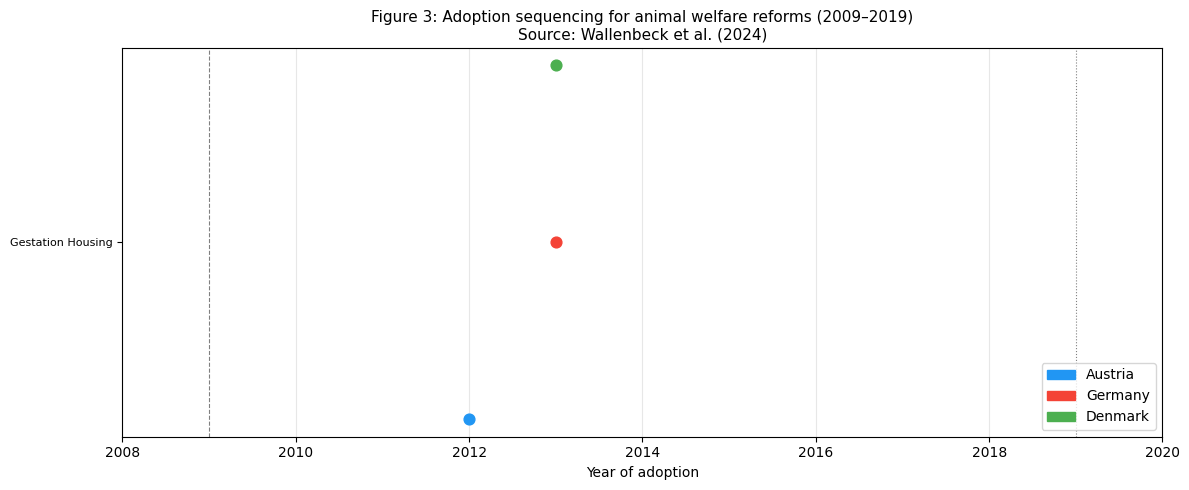

In [16]:
# TIMELINE VISUALISATION (adapted from pig farming visual.ipynb)

country_colors = {'AUT': '#2196F3', 'DEU': '#F44336', 'DNK': '#4CAF50'}
country_labels = {'AUT': 'Austria', 'DEU': 'Germany', 'DNK': 'Denmark'}
country_offsets = {'AUT': -0.15, 'DEU': 0.0, 'DNK': 0.15}

dimensions = pivot_w.index.tolist()
y_positions = range(len(dimensions))

fig, ax = plt.subplots(figsize=(12, max(5, len(dimensions) * 0.5)))

for i, dim in enumerate(dimensions):
    for country in study_countries:
        yr = pivot_w.loc[dim, country]
        if pd.notna(yr):
            ax.scatter(yr, i + country_offsets[country],
                       color=country_colors[country], s=60, zorder=3)

ax.set_yticks(list(y_positions))
ax.set_yticklabels(dimensions, fontsize=8)
ax.set_xlim(2008, 2020)
ax.set_xlabel('Year of adoption')
ax.set_title('Figure 3: Adoption sequencing for animal welfare reforms (2009–2019)\n'
             'Source: Wallenbeck et al. (2024)', fontsize=11)
ax.axvline(2009, color='grey', linestyle='--', linewidth=0.8, label='Study window start')
ax.axvline(2019, color='grey', linestyle=':',  linewidth=0.8, label='Study window end')
ax.grid(axis='x', alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=country_labels[k])
                  for k, c in country_colors.items()]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.savefig('data/fig3_adoption_sequencing_2009_2019.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Qualitative Analysis — AI-Assisted Citation Classification

Applies the De Ruiter & Schalk (2017) taxonomy to each extracted citation context. Mechanism types (informational, legitimating, cautionary) can co-occur; exclusion types (eu_implementation, false_positive, out_of_scope) are mutually exclusive. Results cached at `data/citation_classifications.csv`.

In [17]:
CLASSIFICATION_MODEL = 'claude-haiku-4-5-20251001'
CLASSIFICATION_CACHE = 'data/citation_classifications.csv'

SYSTEM_PROMPT = """You are a research assistant classifying foreign country references in \
parliamentary legislation. This study concerns farmed animal welfare policy diffusion.

The "types" field is a JSON ARRAY. \
Mechanism types (INFORMATIONAL, LEGITIMATING, CAUTIONARY) can co-occur — include every \
type that applies. Exclusion types (EU_IMPLEMENTATION, FALSE_POSITIVE, OUT_OF_SCOPE, \
UNCLEAR) are mutually exclusive and always appear alone.

MECHANISM TYPES (combinable):
INFORMATIONAL: The foreign case is cited to provide factual information about a policy \
elsewhere. Function: inform deliberation. The foreign country is described neutrally or \
descriptively. Example: 'In Denmark, legislation requires enriched cages for laying hens.'

LEGITIMATING: The foreign case is cited to validate or authorise a domestic proposal. \
Function: signal the proposal is mainstream and peer-vetted. Example: 'Like our Danish \
neighbours, we should adopt enriched cages.'

CAUTIONARY: The foreign case is cited as a warning or negative example. Example: \
'Unlike Denmark, which failed to enforce standards, we must act decisively.'

EXCLUSION TYPES (always appear alone, check these in this order):

OUT_OF_SCOPE: The legislative document is not about farmed animal welfare. \
companion animals, wildlife, zoo animals, or other non-farmed animal contexts outside this study's scope.

EU_IMPLEMENTATION: The document is implementing, transposing, or ratifying EU legislation \
that applies jointly to multiple member states. The country is mentioned as a co-signatory, \
co-applicant, or subject of an EU directive or regulation — not as a voluntary peer whose \
policy is being studied or invoked for legitimacy. Applies when the entire legislative \
context is an EU transposition or ratification instrument listing member states collectively.

FALSE_POSITIVE: The country name appears but is NOT a reference to that country as a \
political entity or policy exemplar. Includes: references to the German or Danish \
language ('German translation', 'deutsche Übersetzung'), proper nouns that happen to \
contain a country name, geographic descriptions unrelated to policy, or organisational \
names. Use only when the non-country reading is clearly correct.


UNCLEAR: The function cannot be determined from the available context.

Return ONLY a valid JSON object with these exact keys: \
{"types": <array of one or more labels from the list above, lower-case>, \
 "confidence": "high" | "medium" | "low", \
 "rationale": "<one English sentence>"}

Valid "types" examples: ["informational"], ["legitimating"], ["cautionary"], \
["informational", "legitimating"], ["informational", "cautionary"], \
["legitimating", "cautionary"], ["informational", "legitimating", "cautionary"], \
["eu_implementation"], ["false_positive"], ["out_of_scope"], ["unclear"]"""


def classify_with_claude(contexts_batch, client, model=CLASSIFICATION_MODEL):
    results = []
    for ctx in contexts_batch:
        user_msg = (
            f"Classify this foreign country reference.\n"
            f"Citing country: {ctx.get('citing_country')}\n"
            f"Cited country: {ctx.get('cited_country')}\n"
            f"Document type: {ctx.get('doc_type')}\n"
            f"Context (original language):\n{ctx.get('context', '')}"
        )
        try:
            response = client.messages.create(
                model=model, max_tokens=256,
                system=SYSTEM_PROMPT,
                messages=[{'role': 'user', 'content': user_msg}]
            )
            raw = response.content[0].text.strip()
            # Strip markdown code fences (e.g. ```json\n...\n```) that Haiku sometimes adds
            # backtick-fence pattern: r'^```...' — no escaping needed
            _fence_open  = '^' + '`'*3 + r'(?:json)?\s*\n?'
            _fence_close = r'\n?' + '`'*3 + r'\s*$'
            raw = re.sub(_fence_open,  '', raw)
            raw = re.sub(_fence_close, '', raw).strip()
            parsed = json_lib.loads(raw)
            # Backwards-compat: old single-type responses wrapped into list
            if 'type' in parsed and 'types' not in parsed:
                parsed['types'] = [parsed['type']]
            if not isinstance(parsed.get('types'), list) or not parsed['types']:
                parsed['types'] = ['parse_error']
        except Exception as e:
            parsed = {'types': ['parse_error'], 'confidence': 'low', 'rationale': str(e)}
        results.append(parsed)
    return results

In [18]:
# MANUAL VALIDATION SAMPLE
# Displays the 15 citation contexts used for inter-rater reliability.
# Indices are locked in data/validation_indices.json after first draw.


VALIDATION_CACHE = 'data/validation_indices.json'

if os.path.exists(VALIDATION_CACHE):
    with open(VALIDATION_CACHE) as _f:
        VALIDATION_INDICES = json_lib.load(_f)
    validation_sample = all_contexts.loc[VALIDATION_INDICES]
    sample_n = len(validation_sample)
    print(f'Loaded locked validation sample ({sample_n} rows) from {VALIDATION_CACHE}')
else:
    sample_n = min(15, len(all_contexts))
    validation_sample = all_contexts.sample(n=sample_n, random_state=42)
    VALIDATION_INDICES = validation_sample.index.tolist()
    os.makedirs('data', exist_ok=True)
    with open(VALIDATION_CACHE, 'w') as _f:
        json_lib.dump(VALIDATION_INDICES, _f)
    print(f'Saved validation indices to {VALIDATION_CACHE}')


def _aw_keyword_context(doc_id, doc_type, citing_country, window=300):
    """Return a short context window around the first AW keyword hit in the source document."""
    fm = FIELD_MAP[doc_type]
    id_col, text_col = fm['id'], fm['text']
    corpus_df = corpus[doc_type].get(citing_country)
    if corpus_df is None:
        return None, None, 'corpus slice not found'
    matches = corpus_df[corpus_df[id_col].astype(str) == str(doc_id)]
    if matches.empty:
        return None, None, 'document not found in corpus'
    doc_row = matches.iloc[0]
    match_type = doc_row.get('aw_match_type', 'unknown')
    full_text = normalise(str(doc_row.get(text_col, '')))
    core  = doc_row.get('aw_core_matched',  []) or []
    broad = doc_row.get('aw_broad_matched', []) or []
    if isinstance(core,  str): core  = [t.strip().strip("'") for t in core.strip("[]").split(",")  if t.strip()]
    if isinstance(broad, str): broad = [t.strip().strip("'") for t in broad.strip("[]").split(",") if t.strip()]
    search_terms = list(core) + list(broad) or [
        'tierschutz', 'tierwohl', 'tierhaltung', 'dyrevelfærd', 'dyreværn', 'husdyr',
    ]
    best_match, best_pos = None, len(full_text)
    for term in search_terms:
        pat = re.compile(re.escape(term), re.IGNORECASE | re.UNICODE)
        m = pat.search(full_text)
        if m and m.start() < best_pos:
            best_pos, best_match = m.start(), m
    if best_match is None:
        return None, match_type, f'no AW keyword found (match_type={match_type})'
    kw_start = max(0, best_match.start() - window)
    kw_end   = min(len(full_text), best_match.end() + window)
    return full_text[kw_start:kw_end], match_type, best_match.group()


print(f'=== VALIDATION SAMPLE (n={sample_n}) ===\n')
print('─' * 70)
for i, (_, row) in enumerate(validation_sample.iterrows(), 1):
    print(f'[{i}/{sample_n}]  {row["citing_country"]} → {row["cited_country"]}  |  {row["doc_type"]}')
    print(f'Title: {row.get("title", "(no title)")}')
    print()
    print('── Citation context (±600 chars) ──')
    print(row['context'])
    print()
    kw_ctx, match_type, kw_label = _aw_keyword_context(
        row.get('doc_id', ''), row['doc_type'], row['citing_country']
    )
    print('── AW keyword context (±300 chars) ──')
    if kw_ctx:
        print(f'   keyword: "{kw_label}"  |  entry type: {match_type}')
        print(kw_ctx)
    else:
        print(f'   [{kw_label}]')
    print()
    print('─' * 70)
    print()

Loaded locked validation sample (15 rows) from data/validation_indices.json
=== VALIDATION SAMPLE (n=15) ===

──────────────────────────────────────────────────────────────────────
[1/15]  DK → SE  |  bills
Title: L 57 Forslag til lov om ændring af lov om fødevarer. (Ændret finansiering af kontrolkampagner og kosttilskudskontrol og indførelse af mulighed for rekvireret vejledning).

── Citation context (±600 chars) ──
reningen fair dog, foreningen for biodynamisk jordbrug
(biodynamisk), foreningen muslingeerhvervet (fme), forsvarets
bygnings - & etablissementstjeneste, fs-c.dk (food safety
consult), fødevaredanmark, fødevareexperten,
fødevaregruppen, fødevarekonceptet, gigtforeningen,
greenpeace danmark, grøn hverdag, grønlands
selvstyre, hatting-ks a/s, helsam, helsebranchens
leverandørforening, hestens værn, hjerteforeningen,
horesta, hygiejnegruppen, hygiejne konsulent,
højmarklaboratoriet a/s, international transport danmark,
kantineledernes landsklub, kgh customs services danmark,

In [19]:
# Set ANTHROPIC_API_KEY in your shell before launching Jupyter:
#   export ANTHROPIC_API_KEY=sk-ant-api03-...
# Or uncomment and fill in the line below (do not commit the key):
# os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-api03-...'

if not os.environ.get('ANTHROPIC_API_KEY'):
    raise EnvironmentError(
        "ANTHROPIC_API_KEY not set. "
        "Export it in your shell before launching Jupyter, or set it in this cell."
    )

OSError: ANTHROPIC_API_KEY not set. Export it in your shell before launching Jupyter, or set it in this cell.

In [ ]:
# CONTEXT EXTRACTION AND CLASSIFICATION
# If cache exists, load it; otherwise run classification and save.
# cit_types is stored as a pipe-separated string, e.g. "informational|legitimating".

def parse_types(s):
    """Split a pipe-separated cit_types string into a list."""
    if not isinstance(s, str) or s == '':
        return []
    return [t.strip() for t in s.split('|') if t.strip()]

def has_type(cit_types_str, type_name):
    return type_name in parse_types(cit_types_str)

if os.path.exists(CLASSIFICATION_CACHE):
    print(f'Loading cached classifications from {CLASSIFICATION_CACHE}')
    classified_df = pd.read_csv(CLASSIFICATION_CACHE)
    print(f'Loaded {len(classified_df)} classified contexts.')

else:
    print('No cache found. Running Claude classification...')
    try:
        import anthropic
        client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from env
    except ImportError:
        raise RuntimeError('anthropic package not installed. Run: pip install anthropic')

    ctx_records = all_contexts.to_dict('records')
    print(f'Classifying {len(ctx_records)} citation contexts...')

    classifications = classify_with_claude(ctx_records, client)

    classified_df = all_contexts.copy()
    classified_df['cit_types']      = ['|'.join(r.get('types', ['parse_error'])) for r in classifications]
    classified_df['cit_confidence'] = [r.get('confidence', 'low')   for r in classifications]
    classified_df['cit_rationale']  = [r.get('rationale', '')       for r in classifications]

    classified_df.to_csv(CLASSIFICATION_CACHE, index=False)
    print(f'Saved {len(classified_df)} classified contexts to {CLASSIFICATION_CACHE}')

from collections import Counter
type_counts = Counter(
    t for s in classified_df['cit_types'] for t in parse_types(s)
)
print('\nClassification type distribution (multi-label — counts may sum > N):')
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {t}: {c}')


Loading cached classifications from data/citation_classifications.csv
Loaded 355 classified contexts.

Classification type distribution (multi-label — counts may sum > N):
  out_of_scope: 104
  false_positive: 102
  eu_implementation: 87
  informational: 58
  cautionary: 6
  legitimating: 2


In [ ]:
# INTER-RATER RELIABILITY — COHEN'S KAPPA

MY_LABELS = [
    'out_of_scope',              # [1]
    'out_of_scope',              # [2]
    'out_of_scope',              # [3]
    'informational+cautionary',  # [4]  DE + NL + UK also present
    'out_of_scope',              # [5]
    'out_of_scope',              # [6]
    'out_of_scope',              # [7]
    'out_of_scope',              # [8]
    'out_of_scope',              # [9]
    'false_positive',            # [10]
    'out_of_scope',              # [11]
    'false_positive',            # [12]
    'unclear',                   # [13]  long list context
    'informational',             # [14]
    'out_of_scope',              # [15]
]

def _normalise_label(lbl):
    """Canonical form: sorted components joined with |."""
    parts = sorted(p.strip() for p in lbl.replace('+', '|').split('|') if p.strip())
    return '|'.join(parts)

if len(MY_LABELS) == len(VALIDATION_INDICES):
    from sklearn.metrics import cohen_kappa_score
    ai_labels_raw = classified_df.loc[VALIDATION_INDICES, 'cit_types'].tolist()
    my_labels_norm = [_normalise_label(l) for l in MY_LABELS]
    ai_labels_norm = [_normalise_label(l) for l in ai_labels_raw]
    kappa = cohen_kappa_score(my_labels_norm, ai_labels_norm)
    print(f'Cohen\'s Kappa: {kappa:.3f}')
    if kappa >= 0.60:
        print('Substantial agreement — AI classifications are reportable.')
    elif kappa >= 0.41:
        print('Moderate agreement — consider revising system prompt for ambiguous cases.')
    else:
        print('Low agreement — revise system prompt and reclassify before reporting.')

    print('\nDisagreements:')
    for idx, my, ai in zip(VALIDATION_INDICES, my_labels_norm, ai_labels_norm):
        if my != ai:
            row = classified_df.loc[idx]
            print(f'  #{idx}: you={my}  AI={ai}')
            print(f'    Rationale: {row["cit_rationale"]}')
else:
    print(f'Fill in MY_LABELS with {len(VALIDATION_INDICES)} entries first.')


Cohen's Kappa: 0.281
Low agreement — revise system prompt and reclassify before reporting.

Disagreements:
  #227: you=out_of_scope  AI=false_positive
    Rationale: Sverige appears only as part of an organisational name ('kgh customs services sverige') in a list of consulted stakeholders, not as a reference to Sweden's policy or legislative approach to farmed animal welfare.
  #42: you=out_of_scope  AI=false_positive
    Rationale: The reference to 'deutsche d-ag' and 'deutschland' appears in a hypothetical tax law example involving corporate restructuring, not as a reference to German policy on farmed animal welfare or any comparative policy analysis.
  #182: you=cautionary|informational  AI=informational
    Rationale: Germany is cited as a factual case study describing how classical swine fever entered the Netherlands in 1997-98 via insufficiently cleaned transport from a German area with wild boar outbreaks, providing epidemiological information to support disease transmission arg

In [ ]:
# BINARY INCLUDE/EXCLUDE KAPPA
# The raw multi-class Kappa includes disagreements within the exclusion
# subcategories (false_positive vs out_of_scope), which do not affect the
# analytical sample. This cell computes Kappa on the binary decision only.

from sklearn.metrics import cohen_kappa_score

_excl = {'false_positive', 'out_of_scope', 'eu_implementation', 'parse_error'}

def _binarise(label):
    """0 = excluded, 1 = included in analytical sample."""
    parts = set(str(label).split('|'))
    # 'unclear' is treated as included (kept in analytical sample per methodology)
    return 0 if parts & _excl else 1

# my_labels_norm and ai_labels_norm are defined in the Kappa cell above
human_binary = [_binarise(l) for l in my_labels_norm]
ai_binary    = [_binarise(l) for l in ai_labels_norm]

kappa_binary = cohen_kappa_score(human_binary, ai_binary)
n_agree = sum(h == a for h, a in zip(human_binary, ai_binary))
print(f'Binary include/exclude Kappa: {kappa_binary:.3f}')
print(f'Agreement: {n_agree}/{len(human_binary)} = {n_agree/len(human_binary)*100:.1f}%')
print()
print('Human binary:', human_binary)
print('AI binary:   ', ai_binary)


Binary include/exclude Kappa: 0.762
Agreement: 14/15 = 93.3%

Human binary: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0]
AI binary:    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]


## Section 6: Mixed-Methods Synthesis

This section combines quantitative citation counts (Section 3) with qualitative citation classification (Section 5) in a convergent parallel mixed-methods design (Creswell & Plano Clark, 2011). High citation frequency paired with predominantly informational citations indicates learning; a legitimating citation profile would indicate emulation.

In [ ]:
# INTEGRATION TABLE
# For each (citing → cited) pair: total citations, informational %,
# legitimating %, inferred mechanism, first-mover count.
#
# EU implementation, false positives, and out-of-scope contexts are excluded
# from the peer-diffusion analysis. Their rates are reported separately.

EXCL_TYPES = {'false_positive', 'out_of_scope', 'eu_implementation', 'parse_error'}

def is_excluded_ctx(cit_types_str):
    return any(t in EXCL_TYPES for t in parse_types(cit_types_str))

excluded_mask = classified_df['cit_types'].apply(is_excluded_ctx)
analytical = classified_df[~excluded_mask].copy()

total_n  = len(classified_df)
fp_n     = classified_df['cit_types'].apply(lambda x: has_type(x, 'false_positive')).sum()
oos_n    = classified_df['cit_types'].apply(lambda x: has_type(x, 'out_of_scope')).sum()
eu_n     = classified_df['cit_types'].apply(lambda x: has_type(x, 'eu_implementation')).sum()
peer_n   = len(analytical)

print(f'Total contexts classified:       {total_n}')
print(f'  └─ EU implementation:          {eu_n}  ({eu_n/total_n*100:.1f}%) — vertical diffusion, excluded')
print(f'  └─ False positives:            {fp_n}  ({fp_n/total_n*100:.1f}%) — non-policy name use, excluded')
print(f'  └─ Out of scope:               {oos_n}  ({oos_n/total_n*100:.1f}%) — non-farmed AW citation, excluded')
print(f'  └─ Peer-diffusion contexts:    {peer_n}  ({peer_n/total_n*100:.1f}%) — basis for integration table')
print()

if eu_n / total_n > 0.5:
    print('WARNING: >50% of contexts are EU implementation. Consider adding a ')
    print('transposition-bill filter (cell 20) before drawing conclusions about')
    print('peer-to-peer diffusion.\n')

pairs = [(citing, cited)
         for citing in ['AT', 'DE', 'DK']
         for cited  in ['AT', 'DE', 'DK', 'SE', 'CH', 'NL', 'UK']
         if citing != cited]

wb_map = {'AUT': 'AT', 'DEU': 'DE', 'DNK': 'DK'}
first_mover_by_dim = pivot_w['first_mover'].map(wb_map)

integration_rows = []
for citing, cited in pairs:
    sub = analytical[
        (analytical['citing_country'] == citing) &
        (analytical['cited_country']  == cited)
    ]
    total = len(sub)
    if total == 0:
        continue
    info_pct  = sub['cit_types'].apply(lambda x: has_type(x, 'informational')).sum() / total * 100
    legit_pct = sub['cit_types'].apply(lambda x: has_type(x, 'legitimating')).sum()  / total * 100
    caut_pct  = sub['cit_types'].apply(lambda x: has_type(x, 'cautionary')).sum()    / total * 100

    fm_count = (first_mover_by_dim == cited).sum() if cited in ['AT', 'DE', 'DK'] else 'N/A'

    if info_pct >= 60 and legit_pct < 40:
        mechanism = 'Learning'
    elif legit_pct >= 60:
        mechanism = 'Emulation'
    elif info_pct >= 40 and legit_pct >= 40:
        mechanism = 'Learning + Emulation'
    elif total < 3:
        mechanism = 'Insufficient data'
    else:
        mechanism = 'Mixed/unclear'

    integration_rows.append({
        'Citing → Cited':  f'{citing} → {cited}',
        'Total N':         total,
        'Informational %': round(info_pct, 1),
        'Legitimating %':  round(legit_pct, 1),
        'Cautionary %':    round(caut_pct, 1),
        'Mechanism':       mechanism,
        'First-mover count': fm_count,
    })

integration_df = pd.DataFrame(integration_rows)
print('Table 2: Mixed-methods integration — peer diffusion contexts only\n')
print(integration_df.to_string(index=False))
integration_df.to_csv('data/table2_integration.csv', index=False)


Total contexts classified:       355
  └─ EU implementation:          87  (24.5%) — vertical diffusion, excluded
  └─ False positives:            102  (28.7%) — non-policy name use, excluded
  └─ Out of scope:               104  (29.3%) — non-farmed AW citation, excluded
  └─ Peer-diffusion contexts:    62  (17.5%) — basis for integration table

Table 2: Mixed-methods integration — peer diffusion contexts only

Citing → Cited  Total N  Informational %  Legitimating %  Cautionary %            Mechanism First-mover count
       AT → DE        2            100.0            50.0           0.0 Learning + Emulation                 0
       AT → DK        1            100.0             0.0           0.0             Learning                 0
       AT → SE        1            100.0             0.0           0.0             Learning               N/A
       AT → CH        2            100.0             0.0           0.0             Learning               N/A
       AT → NL        1            

Within-trio analytical citations: 28
    DE  AT  DK
DE   0   2   3
AT   2   0   1
DK  20   0   0
Saved: data/fig1_citation_matrix.png


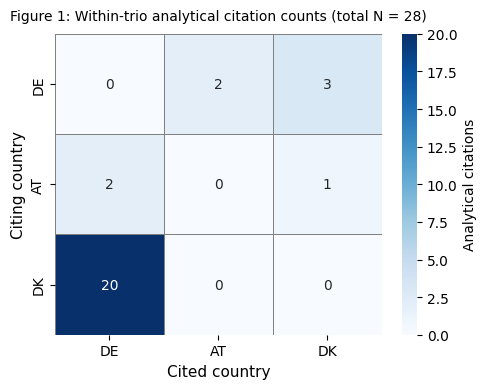

In [ ]:
# FIGURE 1: WITHIN-TRIO ANALYTICAL CITATION MATRIX
# Builds and saves a heatmap of analytical citation counts among DE/AT/DK.

import seaborn as sns

# classified_df is loaded/created in the classification cell above
_excl_types = {'false_positive', 'out_of_scope', 'eu_implementation', 'parse_error'}

def _is_analytical(cit_type_str):
    parts = set(str(cit_type_str).split('|'))
    return not bool(parts & _excl_types)

analytical_df = classified_df[classified_df['cit_types'].apply(_is_analytical)].copy()

trio = ['DE', 'AT', 'DK']
matrix = pd.DataFrame(0, index=trio, columns=trio)

for _, row in analytical_df.iterrows():
    ctr = str(row.get('citing_country', '')).strip()
    ctd = str(row.get('cited_country',  '')).strip()
    if ctr in trio and ctd in trio and ctr != ctd:
        matrix.loc[ctr, ctd] += 1

total_within_trio = matrix.values.sum()
print(f'Within-trio analytical citations: {total_within_trio}')
print(matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matrix,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='grey',
    cbar_kws={'label': 'Analytical citations'},
    ax=ax
)
ax.set_xlabel('Cited country', fontsize=11)
ax.set_ylabel('Citing country', fontsize=11)
ax.set_title(f'Figure 1: Within-trio analytical citation counts (total N = {total_within_trio})',
             fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('data/fig1_citation_matrix.png', dpi=150, bbox_inches='tight')
print('Saved: data/fig1_citation_matrix.png')
plt.show()

In [ ]:
# ── EXPORT: influence_edges.json for product visualisation ───────────────────
# Auto-generates data/influence_edges.json from analytical_df.
# Rerun this notebook (with an updated classifier) to refresh the product map.
# product/influence_map.ipynb reads this file automatically.

import json as _json, os as _os

_PEER = {'informational', 'cautionary', 'legitimating'}

def _mech_counts(grp):
    counts = {}
    for _, row in grp.iterrows():
        for t in str(row['cit_types']).split('|'):
            t = t.strip()
            if t in _PEER:
                counts[t] = counts.get(t, 0) + 1
    return counts

_edges_out = []
for (_src, _tgt), _grp in analytical_df.groupby(['citing_country', 'cited_country']):
    if _src == _tgt:
        continue
    _mc   = _mech_counts(_grp)
    _mech = max(_mc, key=_mc.get) if _mc else 'informational'
    _edges_out.append({
        'src': str(_src), 'tgt': str(_tgt),
        'n':  int(len(_grp)),
        'mechanism': _mech,
        'mechanism_counts': _mc,
    })

_edges_out.sort(key=lambda e: -e['n'])

_export = {
    'note': (
        'Auto-generated by parlawspeechCC_v2.ipynb (export-influence-edges cell). '
        'Rerun with an updated classifier to refresh.'
    ),
    'total_analytical_citations': int(len(analytical_df)),
    'edges': _edges_out,
}

_os.makedirs('data', exist_ok=True)
with open('data/influence_edges.json', 'w') as _f:
    _json.dump(_export, _f, indent=2)

print(f"Exported {len(_edges_out)} edges  ({len(analytical_df)} analytical citations)")
print("Saved: data/influence_edges.json")
for _e in _edges_out[:15]:
    print(f"  {_e['src']} \u2192 {_e['tgt']}:  N = {_e['n']}  ({_e['mechanism']})")
if len(_edges_out) > 15:
    print(f"  ... and {len(_edges_out)-15} more")


In [ ]:
# The IDs used in the paper for the vignettes were the following:
#   Vignette 1 (Cautionary, DK → DE, 2012, disease control):
#     doc_id = 'L 146',  date = '2012-03-29'  (DK bills corpus)
#   Vignette 2 (Informational, DK → DE, 2018, veterinary medicine):
#     doc_id = 'L 61',   date = '2018-10-04'  (DK bills corpus)
#   Vignette 3 (Cautionary, DE → AT, 2017, fur farming):
#     doc_id = '18/12085'                      (DE bills corpus)
# To retrieve: load corpus RDS, filter by bill_ID + initiation_date.

# NARRATIVE VIGNETTES — high-confidence examples of each citation type

high_conf = classified_df[classified_df['cit_confidence'] == 'high']

print('=== ILLUSTRATIVE CITATION CONTEXTS ===\n')

top_cited = matrix_df.sum().drop(['AT','DE','DK'], errors='ignore').idxmax()
print(f'Most cited non-study country: {top_cited}')

for cit_type in ['informational', 'legitimating', 'cautionary']:
    examples = high_conf[
        high_conf['cit_types'].apply(lambda x: has_type(x, cit_type))
    ].head(3)
    print(f'\n--- {cit_type.upper()} examples ---')
    for _, row in examples.iterrows():
        print(f'  [{row["citing_country"]} → {row["cited_country"]}] {row["doc_type"]}')
        print(f'  Types: {row["cit_types"]}')
        print(f'  {row["context"][:400]}')
        print(f'  Rationale: {row["cit_rationale"]}')
        print()


=== ILLUSTRATIVE CITATION CONTEXTS FOR DISSERTATION ===
(Translate selected passages to English for the dissertation text)

Most cited non-study country: CH

--- INFORMATIONAL examples ---
  [AT → DK] bills
  Types: informational
  ein liegebereich gefordert, der „physically comfortable“ ist. die 1. tierhaltungsverordnung (anlage 5, punkt 2) sieht jedoch nur den „zugang zu einem größen- und temperaturmäßig angenehmen liegebereich“ vor. da 92% der schweine, welche auf vollspaltenböden gehalten werden, an den schmerzen von geschwollenen gelenken leiden, kann ein vollspaltenboden somit nicht der eu-richtlinie entsprechen, da er
  Rationale: Denmark is cited as a factual example of a country (the EU's largest pig producer) that has already banned fully slatted floors, providing neutral descriptive information to inform Austrian legislative deliberation on pig housing standards.

  [AT → SE] bills
  Types: informational
  table“ ist. die 1. tierhaltungsverordnung (anlage 5, punkt 2) sieht j